# Zuber (Chigaco nov 2017)
##### Preferencias de los pasajeros y el impacto de los factores externos en los viajes

### PRIMERA PARTE
#### 1. Analizar los datos meteorológicos  

In [7]:
#Analizando datos del clima en Chicago en noviembre de 2017

#importar librerías
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

#solicitud
URL='https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'
req = requests.get(URL)
soup = BeautifulSoup(req.text, 'lxml')
table = soup.find('table', attrs={'id':'weather_records'})
#nombres de columnas
heading_table=[]
for row in table.find_all('th'):
    heading_table.append(row.text)
#contenido de la tabla
content=[]
for row in table.find_all('tr'):
    #que no sea el encabezado
    if not row.find_all('th'):
        content.append([element.text for element in row.find_all('td')])
#crear dataframe
weather_records = pd.DataFrame(content, columns=heading_table)
print(weather_records)

           Date and time Temperature       Description
0    2017-11-01 00:00:00     276.150     broken clouds
1    2017-11-01 01:00:00     275.700  scattered clouds
2    2017-11-01 02:00:00     275.610   overcast clouds
3    2017-11-01 03:00:00     275.350     broken clouds
4    2017-11-01 04:00:00     275.240     broken clouds
..                   ...         ...               ...
692  2017-11-29 20:00:00     281.340        few clouds
693  2017-11-29 21:00:00     281.690      sky is clear
694  2017-11-29 22:00:00     281.070        few clouds
695  2017-11-29 23:00:00     280.060      sky is clear
696  2017-11-30 00:00:00     278.460      sky is clear

[697 rows x 3 columns]


#### 2. Análisis exploratorio (consultas sql)

1. CONSULTA SQL PARA OBTENER LA CANTIDAD DE VIAJES EN TAXI PARA CADA COMPAÑIAPARA EL 15 Y 16 DE NOVIEMBRE DE 2017 
SELECT 
    company_name,
    COUNT(trip_id) AS trips_amount
FROM 
    trips
    LEFT JOIN cabs ON trips.cab_id=cabs.cab_id
WHERE 
    start_ts::date BETWEEN '2017-11-15' AND '2017-11-16' 
GROUP BY 
    company_name
ORDER BY
trips_amount DESC

2. CONSULTA SQL PARA OBTENER CANTIDAD DE VIAJES PARA CADA EMPRESA SI EN SU NOMBRE TIENEN 'Blue' O 'Yellow' DEL 1 AL 7 DE NOVIEMBRE
SELECT
    company_name,
    COUNT(trip_id) AS trips_amount
FROM trips
    LEFT JOIN cabs ON trips.cab_id=cabs.cab_id
WHERE 
    (start_ts::date BETWEEN '2017-11-01' AND '2017-11-07') AND (company_name LIKE '%Blue%' OR company_name LIKE '%Yellow%')
GROUP BY company_name
ORDER BY 
    trips_amount

3. CONSULTA DE SQL PARA OBTENER EL NUMERO DE VIAJES DE LA EMPRESA FLASH CAB Y TAXI AFFILIATION SERVICES DEL 1 AL 7 DE NOVIEMBRE AGRUPANDO LO DEMÁS COMO 'OTHER'
SELECT 
    CASE 
        WHEN company_name IN ('Flash Cab','Taxi Affiliation Services') 
            THEN company_name
        ELSE 'Other'
    END AS company,    
    COUNT(trip_id) AS trips_amount
FROM trips
    INNER JOIN cabs ON trips.cab_id=cabs.cab_id
WHERE 
    start_ts::date BETWEEN '2017-11-01' AND '2017-11-07'
GROUP BY company
ORDER BY trips_amount DESC

#### 3. Pruebla de hipótesis sobre Loop y O'Hale

4. CONSULTA DE SQL PARA OBTENER IDENTIFICADORES DE LAS UBICACIONES. LOOP Y O'HALE. 
SELECT 
    neighborhood_id,
    name
FROM neighborhoods
WHERE name LIKE '%Hare' or name LIKE 'Loop'

5. CPNSULTA DE SQL PARA OBTENER PARA CADA HORA LOS REGISTROS METEREOLÓGICOS DIVIDIENDO EN BUENOS Y MALOS. CONDICIONES CLIMÁTICAS
SELECT 
    ts,
    CASE 
        WHEN description LIKE '%rain%' OR description LIKE '%storm%' THEN 'Bad'
    ELSE 'Good'
    END AS weather_conditions
FROM weather_records 


6. CONSULTA DE SQL PARA OBTENER LA DURACIÓN EN SEGUNDOS, LAS CONDICIONES CLIMÁTICAS (weather_conditions) DE TODOS LOS VIAJES QUE COMENZARON EN EL LOOP ID:50 EL SÁBADO Y TERMINARONN EN O'HARE ID:63 
SELECT
    trips.start_ts,
    CASE 
        WHEN description LIKE '%rain%' OR description LIKE '%storm%' THEN 'Bad'
    ELSE 'Good'
    END AS weather_conditions,
    duration_seconds
FROM trips
    INNER JOIN weather_records ON trips.start_ts=weather_records.ts 
WHERE 
    pickup_location_id = 50 AND dropoff_location_id = 63 AND EXTRACT(DOW FROM trips.start_ts)=6
ORDER BY
trips.trip_id

### SEGUNDA PARTE
#### Exploración de datos
Segunda exploración en python para la prueba de hipótesis

In [8]:
#Cargar los datos

#DF: número de viajes de cada compañia el 15 y 16 de noviembre de 2017
df_trips_company = pd.read_csv(r'C:\Users\marcb\OneDrive\Documentos\TRIPLETEN\proyectos\zuber_project\project8_sql_result_01.csv')
#DF: promedio de viajes terminados en cada barrio en noviembre de 2017
df_dropoffs = pd.read_csv(r'C:\Users\marcb\OneDrive\Documentos\TRIPLETEN\proyectos\zuber_project\project8_sql_result_04.csv')
#DF: Datos meteorologicos de los viajes que van desde Loop hasta O'Hale
df_weather_trips = pd.read_csv(r'C:\Users\marcb\OneDrive\Documentos\TRIPLETEN\proyectos\zuber_project\project8_sql_result_07.csv')

In [9]:
#Exploración de datos

#Definir una funcion para revisar dataframes
def info_df(df):
    print('___________________________________________ Información de Data Frame')
    print(f'                                                                      *')
    df.info()
    print('___________________________________________ Primeras tres filas')
    print(f'                                                                      *')
    print(df.head(3))
    if df.duplicated().sum() != 0:
        print('__________________________________*  !!!  *_______ Duplicados *')
        print(f'                                                                      *')
        print(f'Total duplicados: {df.duplicated().sum()}')
        print('__________________________________*   !   *Muestra:')
        if df.duplicated().sum() >= 3:
            print(df[df.duplicated()].sample(3))
        else: 
            print(df[df.duplicated()].sample())
            
#Definir funcion de estadistica
def distribucion_data(df, columna):
    print('___________________________________________ Descripción estadistica')
    print(f'                                                                      *')
    print(df.describe())
    print('___________________________________________ Dispersión')
    print(f'                                                                      *')
    coef_dispersion = df[columna].std()/df[columna].mean()*100
    mediana = df[columna].median()
    if coef_dispersion < 15:
        print(f'Poca dispersion, {round(coef_dispersion, 3)} %')
    elif coef_dispersion <= 50:
        print(f'Dispersión moderada, {round(coef_dispersion, 3)} %')
    else:
        print(f'Datos muy dispersos, {round(coef_dispersion, 3)} %')
        print(f'Mediana: {round(mediana,3)}')
    plt.figure(figsize=(10,2))
    sns.histplot(data=df, x=columna, bins='fd', kde=True)
    plt.title(f'Histograma de columna: {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()


Nota: bins='fd': en la definicion distribucion_data(), cuando hacemos el histograma, 'fd' (freedman diaconis estimator) toma en cuenta la variabilidad y el tamaño de los datos para definir la cantidad de bins. 'scott' también funcionaría, pero 'fd' es mucho más resiliente a outliers

In [10]:
#df_trips_company: número de viajes de cada compañia el 15 y 16 de noviembre de 2017

#usar funcion info_df()
info_df(df_trips_company)

___________________________________________ Información de Data Frame
                                                                      *
<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB
___________________________________________ Primeras tres filas
                                                                      *
                company_name  trips_amount
0                  Flash Cab         19558
1  Taxi Affiliation Services         11422
2           Medallion Leasin         10367


___________________________________________ Descripción estadistica
                                                                      *
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000
___________________________________________ Dispersión
                                                                      *
Datos muy dispersos, 177.69 %
Mediana: 178.5


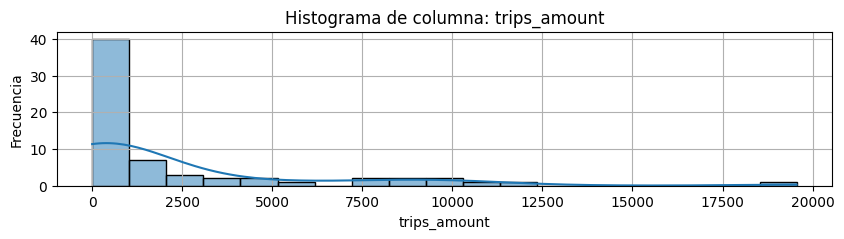

In [11]:
#df_trips_company: número de viajes de cada compañia el 15 y 16 de noviembre de 2017

#usar función distribucion_data
distribucion_data(df_trips_company, 'trips_amount')

Notas:<br>
<br>
Hay 64 empresas de taxis y en promedio hubo 2145.484375 viajes el 15 y 16 de noviembre de 2017. <br>
La menor cantidad de viajes completados por una de las empresas en esas fechas fue de dos viajes, y la empresa con más viajes registro 19558<br>
Los datos están muy dispersos y por cómo se ven los cuartiles, están sesgados a la derecha. El histograma muestra los datos a la izquierda, son sólo muy pocas las empresas las que lideran el mercado con la mayor cantidad de viajes. Y la mayoria de las empresas tienen entre 0 y 2500 viajes<br>

In [12]:
#df_dropoffs: promedio de viajes terminados en cada barrio en noviembre de 2017
#función info_df()
info_df(df_dropoffs)

___________________________________________ Información de Data Frame
                                                                      *
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB
___________________________________________ Primeras tres filas
                                                                      *
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667


___________________________________________ Descripción estadistica
                                                                      *
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667
___________________________________________ Dispersión
                                                                      *
Datos muy dispersos, 285.787 %
Mediana: 52.017


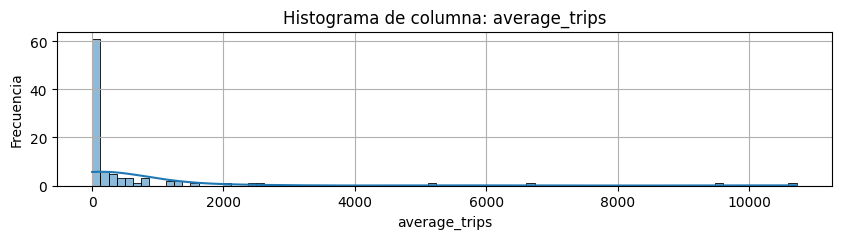

In [13]:
#df_dropoffs: promedio de viajes terminados en cada barrio en noviembre de 2017
#función distribución_data()
distribucion_data(df_dropoffs, 'average_trips')

Notas:<br>
<br>
Los datos están muy dispersos. Las ubicaciones de destino son muy variadas, desde las que tienen de uno a dos viajes terminados en promedio como mínimo en noviembre), hasta la ubicacion con un promedio máximo de apróximadamente 10727 viajes.<br>
Pero podemos ver que la mayoria de las ubicaciones tienen menos de 1000 viajes en promedio para noviembre, y sólo muy pocos barrios superan los 4000.

In [14]:
#df_weather_trips: Datos meteorologicos de los viajes que van desde Loop hasta O'Hale
#funcion info_df()
info_df(df_weather_trips)

___________________________________________ Información de Data Frame
                                                                      *
<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 25.2 KB
___________________________________________ Primeras tres filas
                                                                      *
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
__________________________________*  !!!  *_______ Duplicados *
                             

___________________________________________ Descripción estadistica
                                                                      *
       duration_seconds
count       1068.000000
mean        2071.731273
std          769.461125
min            0.000000
25%         1438.250000
50%         1980.000000
75%         2580.000000
max         7440.000000
___________________________________________ Dispersión
                                                                      *
Dispersión moderada, 37.141 %


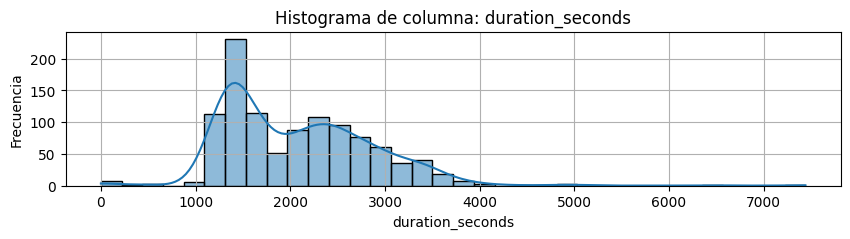

In [15]:
#df_weather_trips: Datos meteorologicos de los viajes que van desde Loop hasta O'Hale
#funcion distribucion_data()
distribucion_data(df_weather_trips, 'duration_seconds')

Notas:<br>
<br>
La duración de los viajes que van desde Loop a O'Hale tiene una duración promedio de 2071.73 segundos. La dispersión es moderada porque la distancia es la misma en gereral y lo que podria hacerla variar son factores externos, precisamente como el clima, el tráfico, o rutas diferentes, etc...<br>
<br>
Pero en min vemos 0. O sea por lo menos uno de los viajes, que son más por lo que se ve en la gráfica, tienen registrados 0 como duracion de viaje. Podria haber errores en los datos, tal vez hay viajes cancelados igual registrados en el sistema, o tal vez hay un error que registra la hora final como 0 tal vez repitiendo la de start_ts, o incluso que el temporizador tenga errores. <br>
<br>
El type de la fecha es object, hay que corregirlo. <br>
En realidad en este caso los duplicados tienen sentido o justificacion. Sólo son duraciones de viaje desde el mismo lugar hasta el mismo destino, de 64 empresas de taxis. Es posible que haya viajes parecidos o incluso idéntidos. <br>


In [16]:
#limpiando datos de weather_trips

#corrigiendo tipos de datos de la columna start_ts
df_weather_trips['start_ts'] = pd.to_datetime(df_weather_trips['start_ts'])

In [17]:
#Revisando df_weather_trips. (el 0 en min de .describe())
trip_dura0 = len(df_weather_trips[df_weather_trips['duration_seconds'] == 0.0]) 
porcentaje_dura0 = trip_dura0 / len(df_weather_trips) * 100
print(f'Hay {trip_dura0} registros de viajes que duran 0 segundos, son el {round(porcentaje_dura0, 2)} % de los datos')

Hay 6 registros de viajes que duran 0 segundos, son el 0.56 % de los datos


In [18]:
#elimar viajes 'vacios' de df_weather_trips 
df_weather_trips = df_weather_trips[df_weather_trips['duration_seconds'] > 0.0]

Nota: <br>
<br>
Son sólo 6, los eliminamos porque no podemos saber a qué se debe el 0 y de que son errores lo son. 0 no tiene sentido como duración de un viaje y son menos del 1% de los datos. 
No tiene caso rellenarlos con la media o mediana porque no podemos estar seguros de que representen viajes reales. Hay un error porque 0.0 no es unvalor faltante. Y eliminándolos evitamos que distorsionen medidas como medias o percentiles.

In [19]:
#Los 10 principales barrios como destino de viajes

locations_top10 = df_dropoffs.sort_values('average_trips', ascending=False).head(10)
print(locations_top10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


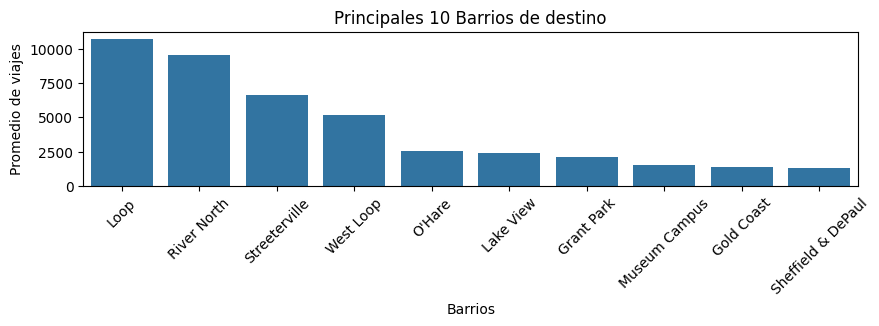

In [20]:
#Los 10 principales barrios como destino de viajes (gráficos)

#gráfico de barras
plt.figure(figsize=(10,2))
sns.barplot(data=locations_top10, x='dropoff_location_name', y='average_trips')
plt.xticks(rotation=45)
plt.title('Principales 10 Barrios de destino')
plt.xlabel('Barrios')
plt.ylabel('Promedio de viajes')
plt.show()

Nota: <br>
<br>
El barrio con más viajes es Loop. West Loop, el cuarto lugar recibe casi la mitad de viajes que Loop, y el décimo sólo el 10%. <br>
El top confirma que la mayoria de los viajes se concentran en muy pocas ubicaciones.

In [21]:
##Las 10 empresas de taxi con más viajes en promedio

companies_top10 = df_trips_company.sort_values('trips_amount', ascending=False).head(10)
print(companies_top10)

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                   Medallion Leasin         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


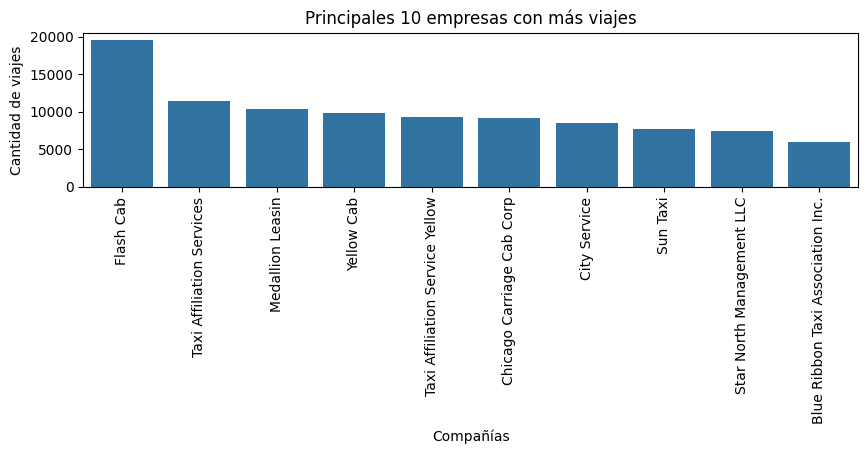

In [22]:
#Las 10 empresas de taxi con más viajes en promedio

#gráfico de barras
plt.figure(figsize = (10,2))
sns.barplot(data = companies_top10, x = 'company_name', y = 'trips_amount')
plt.xticks(rotation = 90)
plt.title('Principales 10 empresas con más viajes')
plt.xlabel('Compañías')
plt.ylabel('Cantidad de viajes')
plt.show()

Nota: <br>
<br>
La empresa con más viajes es Flash Cab, con 19558 viajes.<br>
En segundo lugar, Taxi Affiliation Services tuvo 11426 viajes.<br> Un poco mas de la mitad que Flash Cab.
Desde el segundo lugar en adelante la competencia entre los nueve que quedan es muy similar. Flash Cab parece ser quien domina el mercado. De la función info_df() sabemos que de las 64, hay una empresa con sólo dos viajes registrados entre el 15 y 16 de noviembre. <br>
La industria de los taxis está concentrado en pocas empresas grandes y una que es lider en viajes por aplicación, Flash Cab. 

### Prueba de hipótesis
"La duración promedio de los viajes desde el loop hasta el aeropuerto internacional O'hare cambia los sabados lloviosos'"

                                     Descripcion de Good days
___________________________________________ Descripción estadistica
                                                                      *
                         start_ts  duration_seconds
count                         882        882.000000
mean   2017-11-11 07:33:40.408163       2013.278912
min           2017-11-04 00:00:00         60.000000
25%           2017-11-04 14:00:00       1397.250000
50%           2017-11-11 09:00:00       1800.000000
75%           2017-11-11 16:00:00       2460.000000
max           2017-11-25 23:00:00       7440.000000
std                           NaN        743.565217
___________________________________________ Dispersión
                                                                      *
Dispersión moderada, 36.933 %


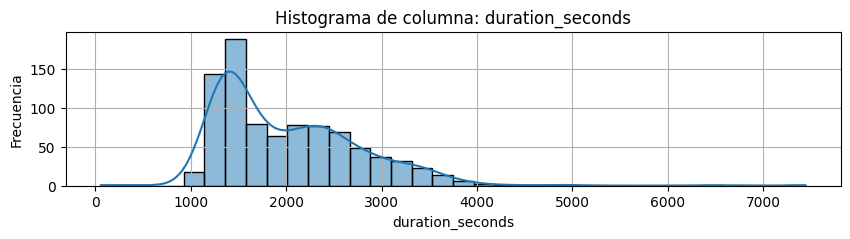

                                     Descripcion de Bad days
___________________________________________ Descripción estadistica
                                                                      *
                  start_ts  duration_seconds
count                  180        180.000000
mean   2017-11-12 08:14:00       2427.205556
min    2017-11-04 16:00:00        480.000000
25%    2017-11-04 17:00:00       1962.000000
50%    2017-11-18 07:00:00       2540.000000
75%    2017-11-18 12:00:00       2928.000000
max    2017-11-18 21:00:00       4980.000000
std                    NaN        721.314138
___________________________________________ Dispersión
                                                                      *
Dispersión moderada, 29.718 %


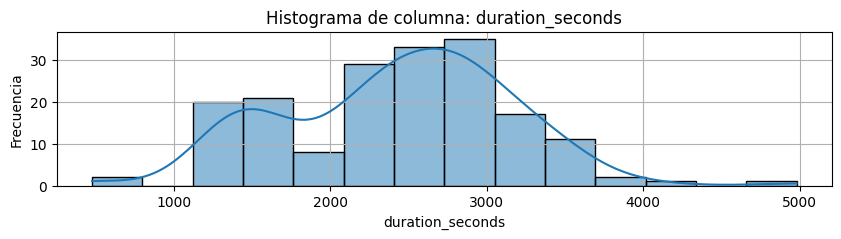

In [23]:
#Preparar los datos

#Extraer datos de sábados
weather_trips_sabado = df_weather_trips[df_weather_trips['start_ts'].dt.weekday == 5]
# parar los dias buenos de los malos

#Días buenos
good = weather_trips_sabado[weather_trips_sabado['weather_conditions'] == 'Good']
#Descripcion
print('                                     Descripcion de Good days')
distribucion_data(good, 'duration_seconds')

#Días malos
bad = weather_trips_sabado[weather_trips_sabado['weather_conditions'] == 'Bad']
#Descripción
print('                                     Descripcion de Bad days')
distribucion_data(bad, 'duration_seconds')

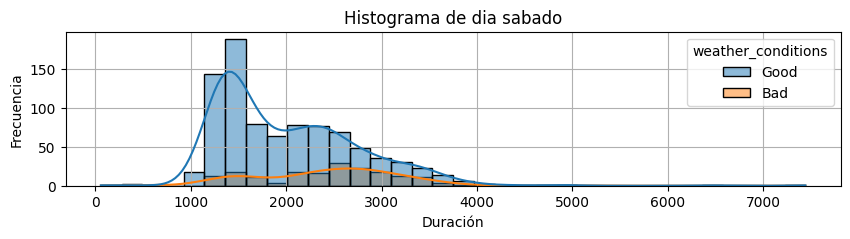

Diferencia de varianzas: 32595.146


In [24]:
#histograma comparativo
plt.figure(figsize=(10,2))
sns.histplot(data=weather_trips_sabado, x='duration_seconds', bins='fd', hue='weather_conditions', kde=True)
plt.title(f'Histograma de dia sabado')
plt.xlabel('Duración')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
#comparacion de varianzas
good_data = good['duration_seconds']
bad_data = bad['duration_seconds']
if pow(good_data.std(), 2) == pow(bad_data.std(), 2):
    print(f'Varianzas idénticas: {pow(good_data.std(), 2)}')
else:
    print(f'Diferencia de varianzas: {round(pow(good_data.std(), 2) - pow(bad_data.std(), 2), 3)}')
                    

In [25]:
#H0: hipótesis nula: La duración promedio es igual en sábados con lluvia y sin lluvia
#Ha: hipótesis alternativa: La duración promedio cambia los sábados cuando llueve de cuando no

#prueba t para muestras independientes
results = st.ttest_ind(good_data, bad_data, equal_var=False)
print(f'valor p: {results.pvalue}')

#criterio

#alpha: nivel de significación alfa
alpha = 0.05
if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula. La duración SÍ cambia con la lluvia')
else:
    print('NO rechazamos la hipótesis nula. No hay suficiente evidencia de que la lluvia afecte la duración de los viajes desde Loop hasta O´Hale')

valor p: 2.417359047158559e-11
Rechazamos la hipótesis nula. La duración SÍ cambia con la lluvia


Nota: <br>
La hipótesis nula es que la duración promedio de los viajes desde Loop hasta O'Hare en sábados con lluvia es igual a la duración promedio en sábados con buen clima.<br>
La hipótesis alternativa es que la duraación promedio es diferente en los sábados lluviosos. No especifica si aumenta o disminuye, por lo que la prueba es bilateral.<br>
El nivel de significación alfa está definido como 0.05. Hay un 5% de probabilidad de rechazar incorrectamente la hipótesis nula, y se eligió ese porque es el más común pero en este caso porque un alfa menor podría no detectar un cambio real.<br>
Estamos comparando dos grupos independientes, por eso se usa la prueba t de Student para muestras independientes. Además sabemos que las varianzas son diferentes así que lo señalamos en equal_var.<br>